• Quais trechos de 1km nas rodovias federais têm densidade de acidentes fatais 3x acima da média nacional? 
 
• Sextas-feiras à noite concentram 30% dos acidentes com embriaguez, enquanto domingos à tarde têm mais colisões traseiras em retornos de viagem? 
 
• Horário de pico em rodovias de acesso às capitais: colisões traseiras são 70% dos acidentes?

Bibliotecas utilizadas

In [3]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import unicodedata
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics import adjusted_rand_score
from sklearn.manifold import TSNE


In [4]:
df_original = pd.read_csv("datatran/datatran_2023_2024_2025.csv")

C:\Users\Hanny\AppData\Local\Temp\ipykernel_7296\1913272631.py:1: DtypeWarning: Columns (25,26) have mixed types. Specify dtype option on import or set low_memory=False.
  df_original = pd.read_csv("datatran/datatran_2023_2024_2025.csv")


# PRÉ PROCESSAMENTO

### Transformação de Dados

In [5]:
df_original['km'] = df_original['km'].str.replace(',', '.', regex=False) # Trocando formatação decimal para evitar perda de dados
df_original['km'] = pd.to_numeric(df_original['km'], errors='coerce')


df = df_original.copy()

### Redução de Dimensionalidade

In [6]:
capitais_brasil = [
    "rio branco",
    "maceio",
    "macapa",
    "manaus",
    "salvador",
    "fortaleza",
    "brasilia",
    "vitoria",
    "goiania",
    "são luis",
    "cuiaba",
    "campo grande",
    "belo horizonte",
    "belem",
    "joão pessoa",
    "curitiba",
    "recife",
    "teresina",
    "rio de janeiro",
    "natal",
    "porto alegre",
    "porto velho",
    "boa vista",
    "florianopolis",
    "são paulo",
    "aracaju",
    "palmas"
]

def normalizar(texto):
    texto = str(texto).strip().lower()
    texto = unicodedata.normalize("NFKD", texto)
    texto = "".join(c for c in texto if not unicodedata.combining(c))
    return texto

def municipio_to_capital(municipio):
    municipio = normalizar(municipio)

    if municipio in capitais_brasil:
        return 1
    else:
        return 0

df['capital'] = df['municipio'].apply(municipio_to_capital)

In [7]:
def classificar_macro_causa(causa):
    if pd.isna(causa):
        return "Outros"
    
    causa = causa.lower()
    
    # --- PEDRESTRE ---
    if "pedestre" in causa:
        return "Pedestre"
    
    # --- AMBIENTE ---
    if any(palavra in causa for palavra in [
        "chuva", "neblina", "fumaça", 
        "acumulo de água", "acumulo de óleo"
    ]):
        return "Ambiente"
    
    # --- MECÂNICA ---
    if any(palavra in causa for palavra in [
        "falhas mecânicas", "freio", "suspensão",
        "pneu", "faróis"
    ]):
        return "Mecânica"
    
    # --- VIA ---
    if any(palavra in causa for palavra in [
        "pista", "curva", "declive", "ondulação",
        "acostamento", "sinalização", "via",
        "obras", "drenagem", "desvio",
        "faixa", "acesso irregular",
        "semáforo com defeito",
        "elemento de contenção",
        "obstrução"
    ]):
        return "Via"
    
    # --- CONDUTOR ---
    if any(palavra in causa for palavra in [
        "condutor", "velocidade", "ultrapassagem",
        "manobra", "transitar", "conversão",
        "frear", "racha", "álcool",
        "reação", "mal súbito",
        "distância", "desrespeitou"
    ]):
        return "Condutor"
    
    return "Outros"


df["macro_causa"] = df["causa_acidente"].apply(classificar_macro_causa)

In [8]:
def mapa_clima(condicao):
    if pd.isna(condicao):
        return "Desconhecido"
    condicao = condicao.strip().lower()
    if condicao in ["céu claro", "sol", "vento"]:
        return "Normal"

    elif condicao in ["chuva", "garoa/chuvisco", "granizo", "neve", "nublado", "nevoeiro/neblina"]:
        return "Adversa"
    
    else:
        return "Desconhecido"
    
df["meteorologia"] = df["condicao_metereologica"].apply(mapa_clima)


In [9]:
def mapa_macro_tipo(tipo):
    if pd.isna(tipo):
        return "Outros"
    
    tipo = tipo.lower()
    
    # --- COLISÕES ENTRE VEÍCULOS ---
    if any(palavra in tipo for palavra in [
        "colisão frontal",
        "colisão traseira",
        "colisão transversal",
        "colisão lateral mesmo sentido",
        "colisão lateral sentido oposto",
        "engavetamento"
    ]):
        return "Colisão entre veículos"
    
    # --- COLISÃO COM OBJETO ---
    if any(palavra in tipo for palavra in [
        "colisão com objeto",
        "derramamento de carga"
    ]):
        return "Colisão com objeto"
    
    # --- PERDA DE CONTROLE / SAÍDA ---
    if any(palavra in tipo for palavra in [
        "saída de leito",
        "capotamento",
        "tombamento"
    ]):
        return "Perda de controle / saída de pista"
    
    # --- ATROPELAMENTO ---
    if "atropelamento" in tipo:
        return "Atropelamento"
    
    # --- SINISTRO INDIVIDUAL ---
    if any(palavra in tipo for palavra in [
        "queda de ocupante",
        "sinistro pessoal"
    ]):
        return "Sinistro individual"
    
    # --- OUTROS ---
    if any(palavra in tipo for palavra in [
        "incêndio",
        "eventos atípicos"
    ]):
        return "Outros"
    
    return "Outros"

df['macro_tipo'] = df['tipo_acidente'].apply(mapa_macro_tipo)

In [10]:
def mapa_fase_dia(fase):

    fase = fase.strip().lower()
    if fase in ["amanhecer", "pleno dia"]:
        return 1
    elif fase in ["plena noite", "anoitecer"]:
        return 0
    
df['dia'] = df['fase_dia'].apply(mapa_fase_dia)

In [11]:
def mapa_dia_semana(dia):

    dia = dia.strip().lower()
    if dia in ["segunda-feira", "terça-feira", "quarta-feira", "quinta-feira", "sexta-feira"]:
        return 1
    elif dia in ["sábado", "domingo"]:
        return 0

    
df['dia_util'] = df['dia_semana'].apply(mapa_dia_semana)

In [12]:
def rodovia_federal(br):
    if br != 0:
        return 1
    else:
        return 0

df['rodovia_federal'] = df['br'].apply(rodovia_federal)

In [13]:
colunas_remover = [
    'id',
    'data_inversa',
    'horario',
    'classificacao_acidente',
    'condicao_metereologica',
    'sentido_via',
    'tracado_via',
    'uso_solo',
    'pessoas',
    'feridos_leves',
    'feridos_graves',
    'ilesos',
    'ignorados',
    'veiculos',
    'latitude',
    'longitude',
    'regional',
    'delegacia',
    'uop',
    'municipio',
    'uf',
    'br',
    'causa_acidente',
    'tipo_acidente',
    'fase_dia',
    'dia_semana',
    'km'
]

df = df.drop(columns=colunas_remover)

### Amostragem Aleatória Simples

foi necessário realizar uma amostragem para execução de alguns algoritmos de maior complexidade de O

In [14]:
df_sample = df.sample(20000, random_state=42)
df_sample

,tipo_pista,mortos,feridos,capital,macro_causa,meteorologia,macro_tipo,dia,dia_util,rodovia_federal
51217,Simples,0,1,0,Condutor,Normal,Colisão entre veículos,1,0,1
41702,Simples,1,0,0,Pedestre,Normal,Atropelamento,0,0,1
203655,Dupla,0,1,0,Condutor,Adversa,Perda de controle / saída de pista,1,0,1
196603,Dupla,0,1,0,Pedestre,Normal,Atropelamento,1,1,1
147195,Simples,0,2,0,Via,Normal,Colisão entre veículos,1,1,1
...,...,...,...,...,...,...,...,...,...,...
1684,Dupla,0,1,0,Condutor,Adversa,Colisão entre veículos,0,0,1
67679,Simples,0,5,0,Outros,Normal,Colisão entre veículos,0,1,1
170271,Simples,0,1,0,Condutor,Adversa,Colisão entre veículos,0,1,1
143555,Dupla,0,1,0,Via,Normal,Colisão entre veículos,1,1,1


### One-Hot Encoding

foi necessário realizar transformação de atributos categóricos em numéricos para execução de algoritmos baseados em distância

In [15]:
categoricas = [
    'macro_causa',
    'macro_tipo',
    'tipo_pista',
    'meteorologia'
]

df_encoded = pd.get_dummies(df_sample, columns=categoricas, drop_first=False)
df_encoded

,mortos,feridos,capital,dia,dia_util,rodovia_federal,macro_causa_Ambiente,macro_causa_Condutor,macro_causa_Mecânica,macro_causa_Outros,...,macro_tipo_Colisão entre veículos,macro_tipo_Outros,macro_tipo_Perda de controle / saída de pista,macro_tipo_Sinistro individual,tipo_pista_Dupla,tipo_pista_Múltipla,tipo_pista_Simples,meteorologia_Adversa,meteorologia_Desconhecido,meteorologia_Normal
51217,0,1,0,1,0,1,False,True,False,False,...,True,False,False,False,False,False,True,False,False,True
41702,1,0,0,0,0,1,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True
203655,0,1,0,1,0,1,False,True,False,False,...,False,False,True,False,True,False,False,True,False,False
196603,0,1,0,1,1,1,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
147195,0,2,0,1,1,1,False,False,False,False,...,True,False,False,False,False,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1684,0,1,0,0,0,1,False,True,False,False,...,True,False,False,False,True,False,False,True,False,False
67679,0,5,0,0,1,1,False,False,False,True,...,True,False,False,False,False,False,True,False,False,True
170271,0,1,0,0,1,1,False,True,False,False,...,True,False,False,False,False,False,True,True,False,False
143555,0,1,0,1,1,1,False,False,False,False,...,True,False,False,False,True,False,False,False,False,True


In [16]:
df_encoded['mortos_log'] = np.log1p(df_encoded['mortos'])
df_encoded['feridos_log'] = np.log1p(df_encoded['feridos'])

### Normalização

foi necessário realizar normalização dos atributos para execução de algoritmos baseados em distância

In [17]:
cols_continuas = ['mortos_log', 'feridos_log']

scaler = StandardScaler()
df_encoded[cols_continuas] = scaler.fit_transform(df_encoded[cols_continuas])

df_scaled = df_encoded

print(df_encoded)

        mortos  feridos  capital  dia  dia_util  rodovia_federal  \
51217        0        1        0    1         0                1   
41702        1        0        0    0         0                1   
203655       0        1        0    1         0                1   
196603       0        1        0    1         1                1   
147195       0        2        0    1         1                1   
...        ...      ...      ...  ...       ...              ...   
1684         0        1        0    0         0                1   
67679        0        5        0    0         1                1   
170271       0        1        0    0         1                1   
143555       0        1        0    1         1                1   
167750       0        1        0    1         0                1   

        macro_causa_Ambiente  macro_causa_Condutor  macro_causa_Mecânica  \
51217                  False                  True                 False   
41702                  False   

# ANÁLISE EXPLORATÓRIA

### Descrição e histogramas

A partir da descrição dos dados, é observável que a maioria dos acidentes reportados não constaram óbitos, mas tiveram ao menos um ferido. Ao mesmo tempo, nota-se a grande discrepância entre essas contagens, assumindo em casos extremos valores como 37 e 84 mortos e feridos, respectivamente.

              mortos        feridos
count  213418.000000  213418.000000
mean        0.083536       1.154978
std         0.348519       1.208910
min         0.000000       0.000000
25%         0.000000       1.000000
50%         0.000000       1.000000
75%         0.000000       1.000000
max        37.000000      84.000000


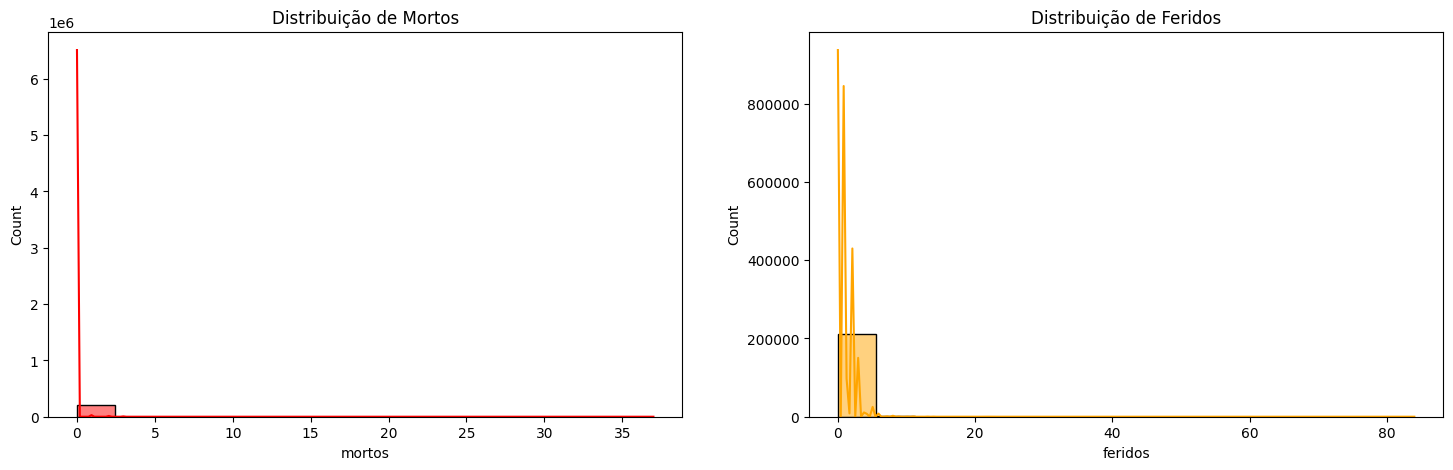

In [18]:
print(df[['mortos', 'feridos']].describe())

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

sns.histplot(df['mortos'], bins=15, ax=axes[0], kde=True, color='red')
axes[0].set_title('Distribuição de Mortos')

sns.histplot(df['feridos'], bins=15, ax=axes[1], kde=True, color='orange')
axes[1].set_title('Distribuição de Feridos')

plt.show()

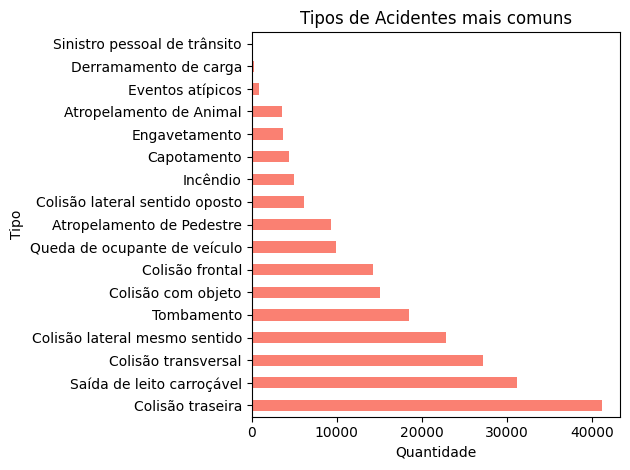

In [19]:
# Histograma para Tipo de Acidente (Horizontal)
df_original['tipo_acidente'].value_counts().plot(kind='barh', color='salmon')

plt.title('Tipos de Acidentes mais comuns')
plt.xlabel('Quantidade')
plt.ylabel('Tipo')
plt.tight_layout() # Ajusta o layout para não cortar o texto
plt.show()

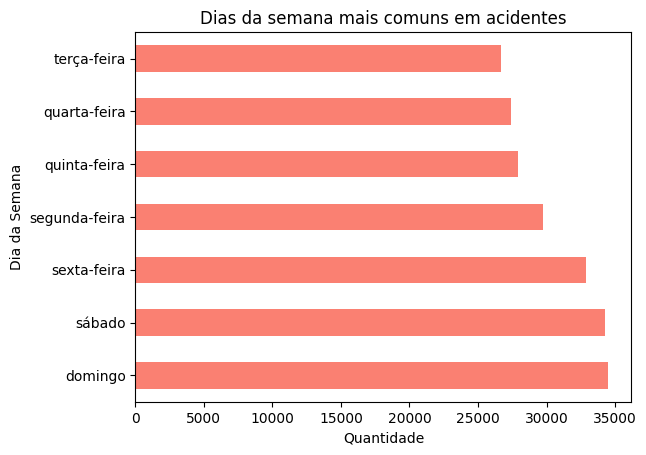

In [20]:
df_original['dia_semana'].value_counts().plot(kind='barh', color='salmon')

plt.title('Dias da semana mais comuns em acidentes')
plt.xlabel('Quantidade')
plt.ylabel('Dia da Semana')
plt.show()

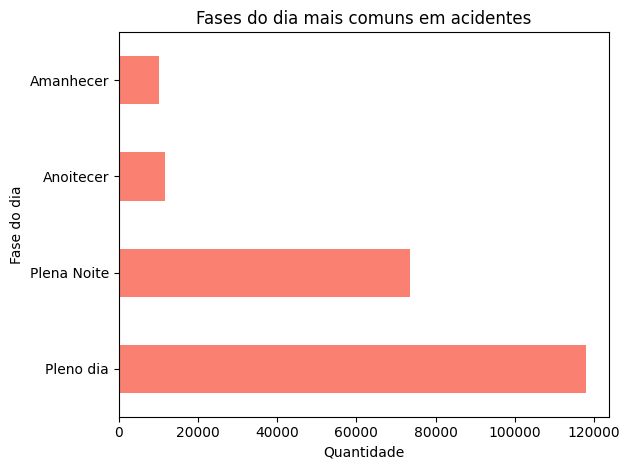

In [21]:
df_original['fase_dia'].value_counts().plot(kind='barh', color='salmon')

plt.title('Fases do dia mais comuns em acidentes')
plt.xlabel('Quantidade')
plt.ylabel('Fase do dia')
plt.tight_layout() 
plt.show()

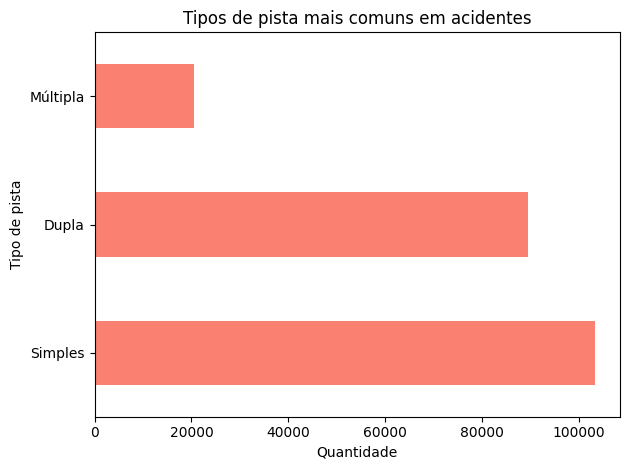

In [22]:
df_original['tipo_pista'].value_counts().plot(kind='barh', color='salmon')

plt.title('Tipos de pista mais comuns em acidentes')
plt.xlabel('Quantidade')
plt.ylabel('Tipo de pista')
plt.tight_layout() 
plt.show()

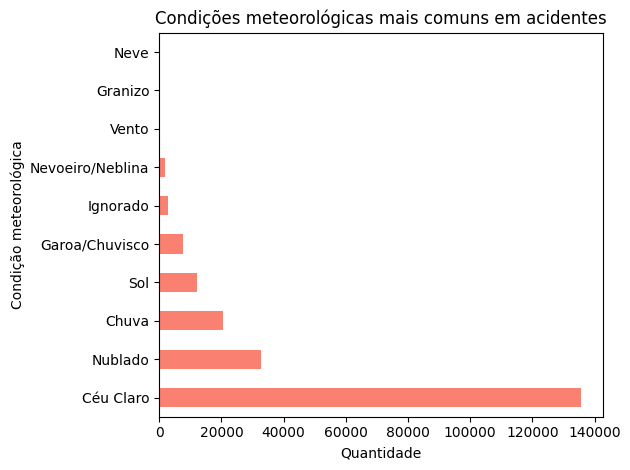

In [23]:
df_original['condicao_metereologica'].value_counts().plot(kind='barh', color='salmon')

plt.title('Condições meteorológicas mais comuns em acidentes')
plt.xlabel('Quantidade')
plt.ylabel('Condição meteorológica')
plt.tight_layout() 
plt.show()

A maioria dos acidentes reportados aconteceram durante a tarde em dias úteis. No entanto, os acidentes graves estão majoritariamente concentrados nas sextas e finais de semana à noite

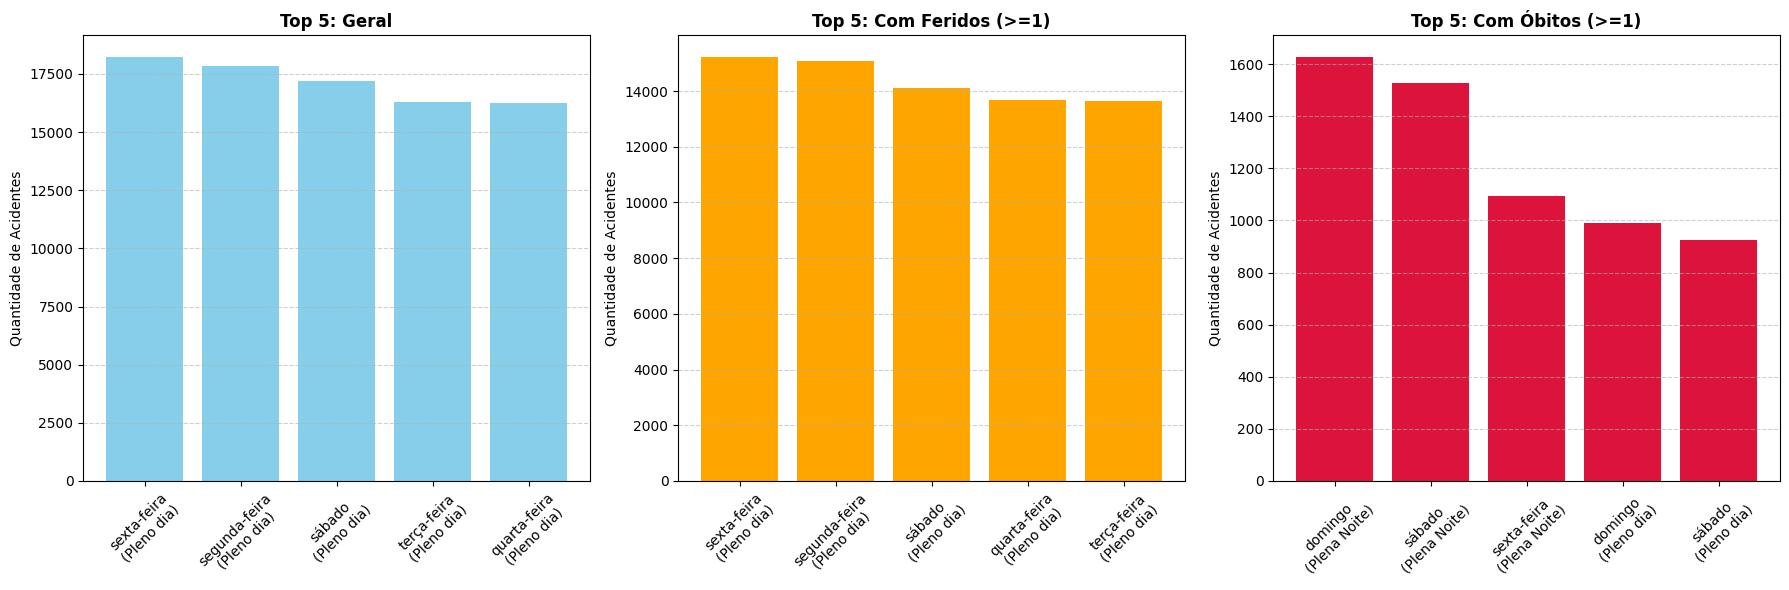

In [24]:
def pegar_top5(dataframe):
    temp = dataframe.groupby(['dia_semana', 'fase_dia']).size().reset_index(name='contagem')
    temp = temp.sort_values(by='contagem', ascending=False).head(5)
    temp['legenda'] = temp['dia_semana'] + "\n(" + temp['fase_dia'] + ")"
    return temp

df_geral = pegar_top5(df_original)
df_feridos = pegar_top5(df_original[df_original['feridos'] >= 1]) 
df_obitos = pegar_top5(df_original[df_original['mortos'] >= 1])   

fig, ax = plt.subplots(1, 3, figsize=(18, 6))

ax[0].bar(df_geral['legenda'], df_geral['contagem'], color='skyblue')
ax[0].set_title('Top 5: Geral', fontweight='bold')

ax[1].bar(df_feridos['legenda'], df_feridos['contagem'], color='orange')
ax[1].set_title('Top 5: Com Feridos (>=1)', fontweight='bold')

ax[2].bar(df_obitos['legenda'], df_obitos['contagem'], color='crimson')
ax[2].set_title('Top 5: Com Óbitos (>=1)', fontweight='bold')

for a in ax:
    a.tick_params(axis='x', rotation=45)
    a.set_ylabel('Quantidade de Acidentes')
    a.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout() 
plt.show()

### Boxplot

Os plots de **mortos** e **feridos** contém grande concentração próximas de zero, indicando que a grande maioria dos registros não causaram óbito ou ferimento. Ambos também apresentam grande quantidade de outliers.

A análise do boxplot de **mortos** demonstra que apesar dos acidentes com vítimas serem exceção, podem atingir uma grande proporção de vítimas quando ocorrem.

No caso de **feridos**, há uma concentração maior de ocorrências de cerca de um a quarenta feridos. Com o caso mais extremo constando 80 feridos.

Já a análise da **quilometragem** demonstra que metade dos registros ocorreu antes dos 200km rodados, e a outra metade depois. A maior parte dos eventos ocorre entre 100 e 400km. Mas apesar de haver uma forte concentração de dados no início das rodovias, a base de dados cobre acidentes ocorridos em maiores extensões, chegando a trechos mais remotos

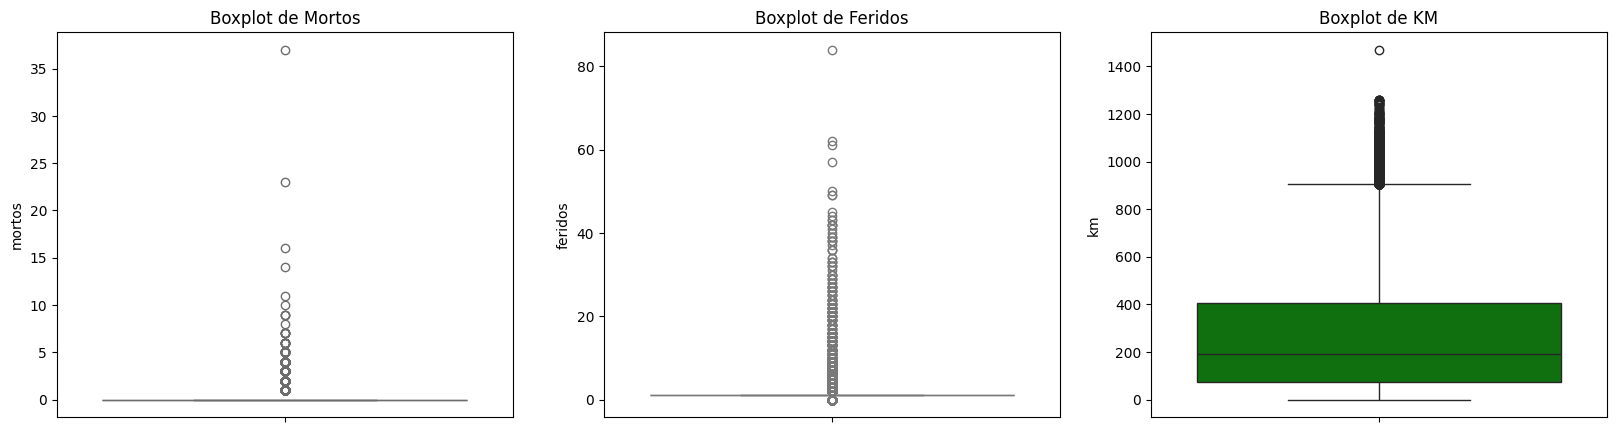

In [25]:
plt.figure(figsize=(20, 5))

plt.subplot(1, 3, 1)
sns.boxplot(data=df_original, y='mortos', color='salmon')
plt.title('Boxplot de Mortos')

plt.subplot(1, 3, 2)
sns.boxplot(data=df_original, y='feridos', color='lightblue')
plt.title('Boxplot de Feridos')

plt.subplot(1, 3, 3)
sns.boxplot(data=df_original, y='km', color='green')
plt.title('Boxplot de KM')

plt.show()

#### Análise de Outliers com base no Bloxpot

De acordo com a regra de IQR, qualquer acidente que contenha mortos e feridos são considerados outliers. No entanto, devido ao nosso interesse em analisar um cluster de acidentes graves, optamos pela não remoção destes.

In [26]:
# Regra de IQR (Tukey)

Q1 = df['mortos'].quantile(0.25)
Q3 = df['mortos'].quantile(0.75)
IQR = Q3 - Q1 # IQR (Intervalo Interquantil): mede a dispersão dos 50% centráis 

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df[(df['mortos'] < limite_inferior) | (df['mortos'] > limite_superior)]

print("outliers são aqueles com número de mortos menor que", limite_inferior, "ou maior que", limite_superior)

outliers são aqueles com número de mortos menor que 0.0 ou maior que 0.0


In [27]:
# Regra de IQR (Tukey)

Q1 = df['feridos'].quantile(0.25)
Q3 = df['feridos'].quantile(0.75)
IQR = Q3 - Q1 # IQR (Intervalo Interquantil): mede a dispersão dos 50% centráis 

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df[(df['feridos'] < limite_inferior) | (df['feridos'] > limite_superior)]

print("Outliers são aqueles com número de feridos menor que", limite_inferior, "ou maior que", limite_superior)

Outliers são aqueles com número de feridos menor que 1.0 ou maior que 1.0


### Rankeamento de acidentes graves

In [28]:
print("Acidentes com maior número de óbitos:")
display(df.nlargest(5, 'mortos'))

print("Acidentes com maior número de feridos:")
display(df.nlargest(5, 'feridos'))

Acidentes com maior número de óbitos:


,tipo_pista,mortos,feridos,capital,macro_causa,meteorologia,macro_tipo,dia,dia_util,rodovia_federal
86272,Simples,37,13,0,Outros,Normal,Colisão entre veículos,0,0,1
68690,Simples,23,9,0,Condutor,Normal,Colisão entre veículos,0,0,1
204845,Simples,16,21,0,Condutor,Normal,Perda de controle / saída de pista,0,1,1
85803,Simples,14,1,0,Via,Normal,Sinistro individual,1,0,1
151791,Simples,11,42,0,Condutor,Normal,Colisão entre veículos,0,1,1


Acidentes com maior número de feridos:


,tipo_pista,mortos,feridos,capital,macro_causa,meteorologia,macro_tipo,dia,dia_util,rodovia_federal
86251,Simples,5,84,0,Condutor,Normal,Colisão com objeto,0,1,1
2963,Simples,3,62,0,Condutor,Adversa,Colisão entre veículos,0,1,1
14996,Dupla,0,61,0,Condutor,Normal,Colisão entre veículos,0,1,1
140902,Simples,4,57,0,Condutor,Adversa,Perda de controle / saída de pista,0,1,1
54666,Dupla,2,50,0,Condutor,Adversa,Perda de controle / saída de pista,0,1,1


### Matriz de Correlação

Foi observado que não há ocorrência de variáveis altamente correlacionadas dentre os atributos que escolhemos para prosseguir a análise. Dessa forma, a redução de redundância não se fez necessária.

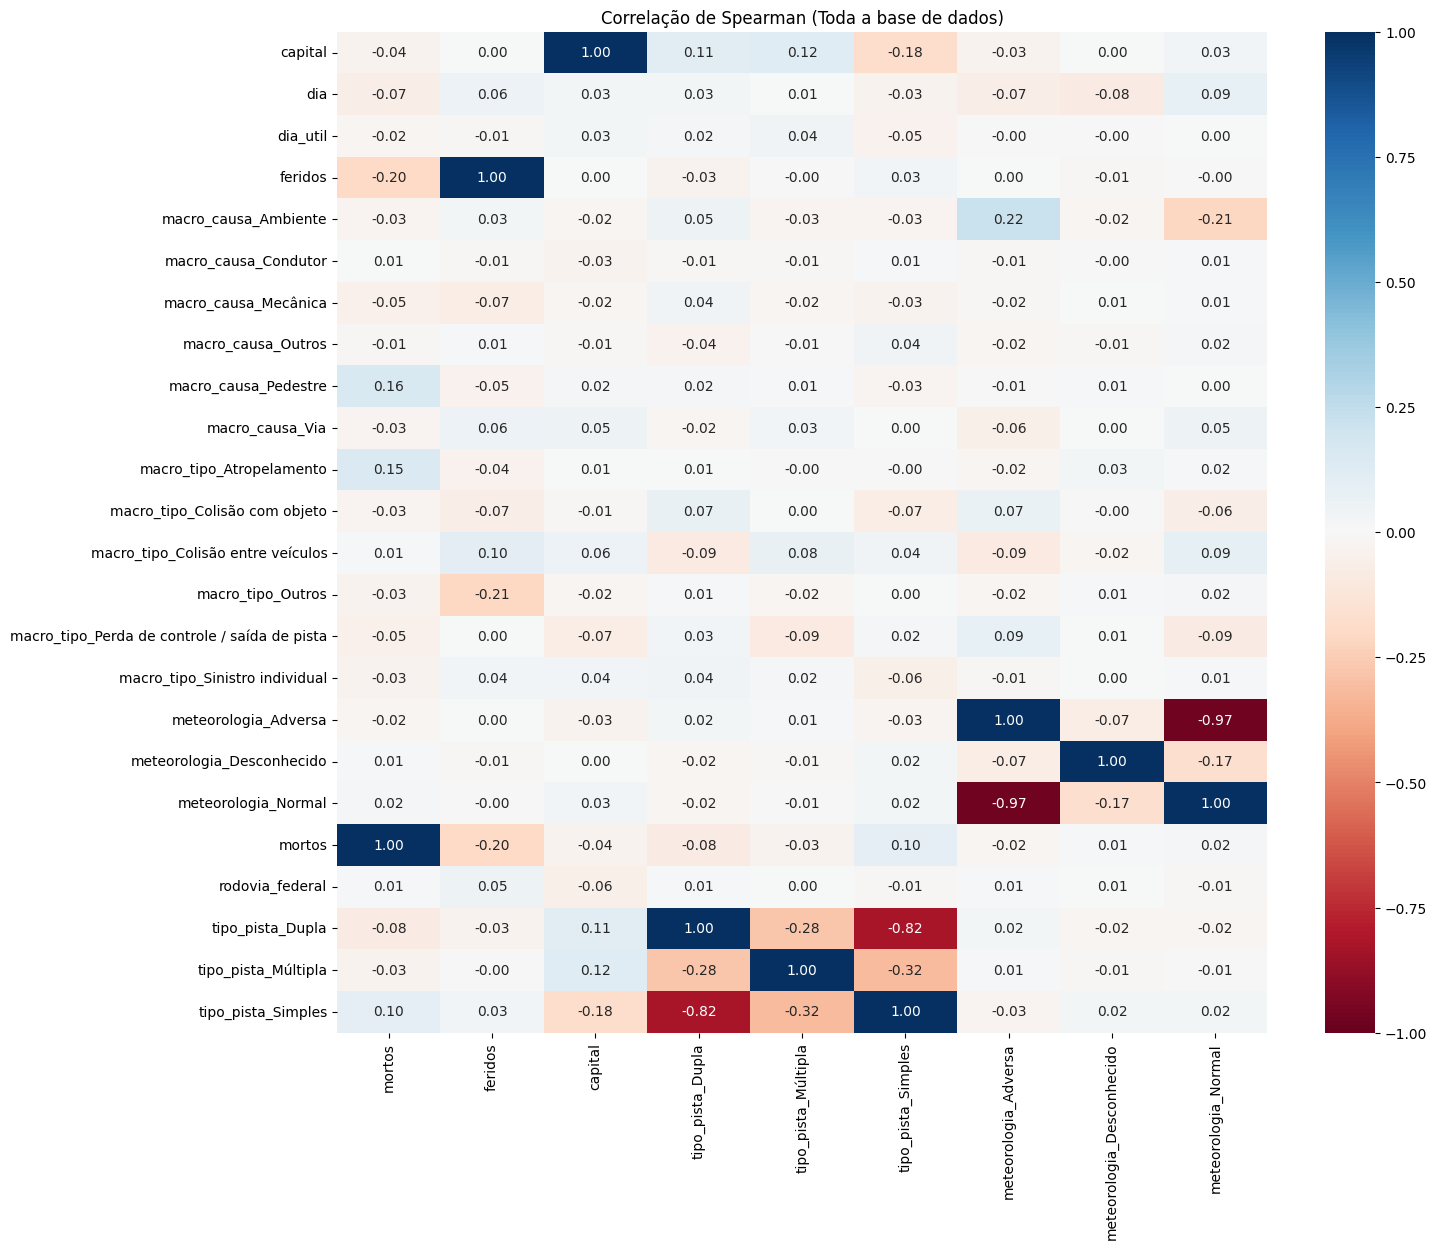

In [29]:
# Selecionando apenas as colunas relacionadas a vítimas, quilometragem, dia de semana e fase do dia
colunas_interesse = ['mortos', 'feridos', 'capital', 'rodovia_federal', 'dia', 'dia_util'] + [c for c in df_encoded.columns if 'meteorologia' in c or 'tipo_pista' in c or 'macro_causa' in c or 'macro_tipo' in c]
corr_df = df_encoded[colunas_interesse].corr(method='spearman')

# Variáveis de interesse para correlação 
vars_corr = ['mortos', 'feridos', 'capital'] + [c for c in df_encoded.columns if 'meteorologia' in c or 'tipo_pista' in c]
target_corr = corr_df[vars_corr].sort_index()

plt.figure(figsize=(15, 13))
sns.heatmap(target_corr, annot=True, cmap='RdBu', center=0, fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlação de Spearman (Toda a base de dados)')
plt.show()

#### Análise Para Acidentes Graves
Foi feita uma filtragem para entender qual a relação dos atributos com os acidentes que obtiveram ao menos um ferido e/ou um óbito. A matriz indica que não há grande correlação dos atributos com a gravidade do acidente. 

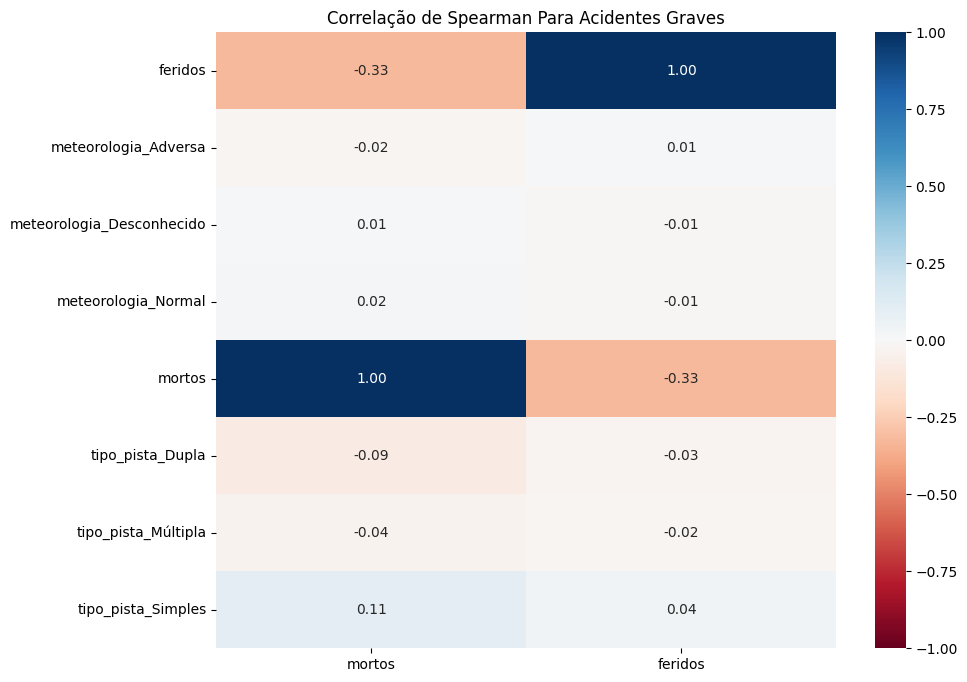

In [30]:
df_com_vitimas = df_encoded[df_encoded['mortos'] + df_encoded['feridos'] > 0].copy()

# Selecionando apenas as colunas relacionadas a vítimas, quilometragem, dia de semana e fase do dia
colunas_interesse = ['mortos', 'feridos'] + [c for c in df_encoded.columns if 'dia_semana' in c or 'fase_dia' in c or 'meteorologia' in c or 'tipo_pista' in c]
corr_com_vitimas = df_com_vitimas[colunas_interesse].corr(method='spearman')

plt.figure(figsize=(10, 8))

# Verificando a correlação de todas as variáveis apenas contra 'mortos' e 'feridos'
target_corr = corr_com_vitimas[['mortos', 'feridos']].sort_values(by='mortos', ascending=False)

# Ordenar o eixo y alfabeticamente
target_corr = target_corr.sort_index()

sns.heatmap(target_corr, annot=True, cmap='RdBu', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlação de Spearman Para Acidentes Graves')
plt.show()

### Análise de Componentes Principais (PCA)

A análise de PCA confirma a inviabilidade de reduzir a dimensionalidade. É demonstrado que cada componente traz uma informação única e relevante, não havendo variáveis discrepantemente dominantes. Sendo assim, os acidentes são fenômenos multifatoriais, que dependem de uma combinação equilibrada de diversos fatores.

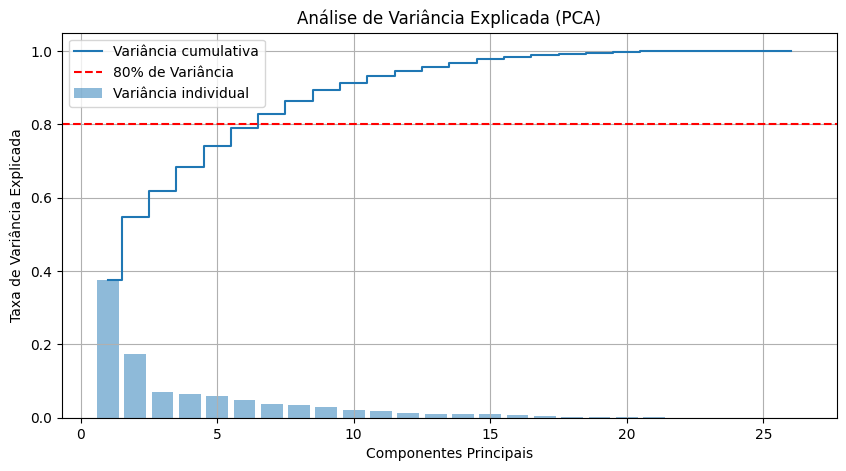

In [31]:
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(df_scaled)
exp_var_cumulativa = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(10, 5))
plt.bar(range(1, len(exp_var_cumulativa) + 1), pca.explained_variance_ratio_, alpha=0.5, align='center', label='Variância individual')
plt.step(range(1, len(exp_var_cumulativa) + 1), exp_var_cumulativa, where='mid', label='Variância cumulativa')
plt.ylabel('Taxa de Variância Explicada')
plt.xlabel('Componentes Principais')
plt.title('Análise de Variância Explicada (PCA)')
plt.axhline(y=0.8, color='r', linestyle='--', label='80% de Variância')
plt.legend(loc='best')
plt.grid(True)
plt.show()

# ALGORITMOS

## K-means

Após muitas testagens, foi observado que a mudança de dimensionalidade proveniente da exclusão das colunas relacionadas à causa e tipo do acidente melhoraram significativamente o desempenho do método de clusterização. Por isso, a partir daqui trabalharemos com uma versão reduzida do nosso dataset, passando de 26 para 9 colunas.

In [32]:
df_scaled.columns

Index(['mortos', 'feridos', 'capital', 'dia', 'dia_util', 'rodovia_federal',
       'macro_causa_Ambiente', 'macro_causa_Condutor', 'macro_causa_Mecânica',
       'macro_causa_Outros', 'macro_causa_Pedestre', 'macro_causa_Via',
       'macro_tipo_Atropelamento', 'macro_tipo_Colisão com objeto',
       'macro_tipo_Colisão entre veículos', 'macro_tipo_Outros',
       'macro_tipo_Perda de controle / saída de pista',
       'macro_tipo_Sinistro individual', 'tipo_pista_Dupla',
       'tipo_pista_Múltipla', 'tipo_pista_Simples', 'meteorologia_Adversa',
       'meteorologia_Desconhecido', 'meteorologia_Normal', 'mortos_log',
       'feridos_log'],
      dtype='object')

In [33]:
df_scaled_menor = df_scaled[[c for c in df_scaled.columns if 'dia_semana' in c or 'fase_dia' in c or 'meteorologia' in c or 'tipo_pista' in c or c in ['mortos_log', 'feridos_log', 'capital', 'dia', 'dia_util']]]

df_scaled_menor.columns

Index(['capital', 'dia', 'dia_util', 'tipo_pista_Dupla', 'tipo_pista_Múltipla',
       'tipo_pista_Simples', 'meteorologia_Adversa',
       'meteorologia_Desconhecido', 'meteorologia_Normal', 'mortos_log',
       'feridos_log'],
      dtype='object')

### Método do Cotovelo

Aplicando o método do cotovelo para determinar o número ideal de clusters para K-means. O gráfico resultante mostra a soma dos erros quadráticos (inércia) para diferentes valores de K, e o "cotovelo" indica o ponto onde a redução da inércia começa a diminuir significativamente, sugerindo o número ideal de clusters.

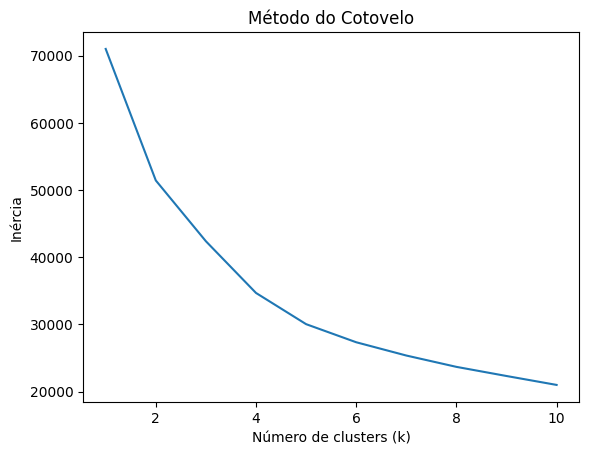

In [34]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(
        n_clusters=k,
        init="k-means++",
        random_state=42,
        n_init=10
    )
    kmeans.fit(df_scaled_menor)
    inertia.append(kmeans.inertia_)

plt.plot(k_range, inertia)
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inércia")
plt.title("Método do Cotovelo")
plt.show()

### Silhouette Score

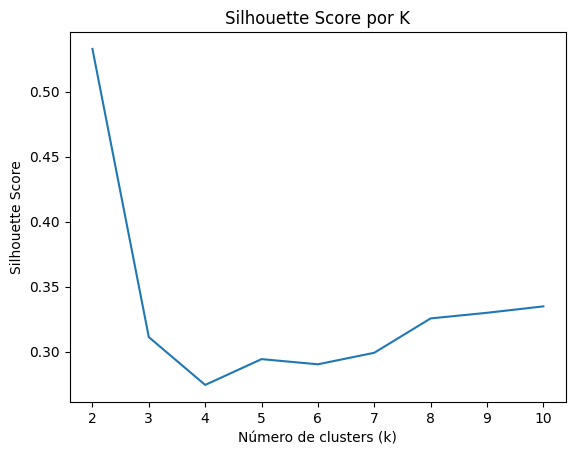

In [35]:
from sklearn.metrics import silhouette_score

sil_scores = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        init="k-means++",
        random_state=42,
        n_init=20
    )
    labels = kmeans.fit_predict(df_scaled_menor)
    sil_scores.append(silhouette_score(df_scaled_menor, labels))

plt.plot(range(2, 11), sil_scores)
plt.xlabel("Número de clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score por K")
plt.show()

Levando em consideração os valores dados pelo silhouette score e a taxa de SSE, vamos fazer a testagem considerando as k quantidade de clusters: 2, 4, 5, 8

### ARI

In [36]:
seeds = [0, 1, 2, 42, 100]
ks = [2, 4, 5, 8]

for k in ks:

    labels_por_semente = []
    
    print(f"\nAvaliando estabilidade para k={k}...")
    
    for s in seeds:
        km_teste = KMeans(n_clusters=k, init='k-means++', random_state=s, n_init=10)
        labels_teste = km_teste.fit_predict(df_scaled_menor)
        labels_por_semente.append(labels_teste)

    ari_do_k = []
    for i in range(len(labels_por_semente)):
        for j in range(i + 1, len(labels_por_semente)):
            score = adjusted_rand_score(labels_por_semente[i], labels_por_semente[j])
            ari_do_k.append(score)

    print(f"-> ARI Médio para k={k}: {np.mean(ari_do_k):.4f}")
    if np.mean(ari_do_k) > 0.8:
        print("Consistência ideal entre sementes")
    else:
        print("Os grupos mudam muito conforme a semente")


Avaliando estabilidade para k=2...
-> ARI Médio para k=2: 1.0000
Consistência ideal entre sementes

Avaliando estabilidade para k=4...
-> ARI Médio para k=4: 0.6648
Os grupos mudam muito conforme a semente

Avaliando estabilidade para k=5...
-> ARI Médio para k=5: 1.0000
Consistência ideal entre sementes

Avaliando estabilidade para k=8...
-> ARI Médio para k=8: 0.8159
Consistência ideal entre sementes


Os resultados indicam que a quantidade de clusters mais estáveis são: k=2, k=5 ou k=8

### Aplicação do Algoritmo

#### Para k = 2

In [37]:
kmeans_k_2 = KMeans(n_clusters=2, init="k-means++", random_state=42)
df_sample["cluster_k_2"] = kmeans_k_2.fit_predict(df_scaled_menor)
df_sample.groupby("cluster_k_2").mean(numeric_only=True)

,mortos,feridos,capital,dia,dia_util,rodovia_federal
cluster_k_2,,,,,,
0,0.014939,1.676343,0.114883,0.628593,0.689202,0.998676
1,0.162351,0.586375,0.052525,0.565789,0.670840,0.995331


Nota-se uma distribuição proporcional entre os clusters

In [38]:
df_sample["cluster_k_2"].value_counts()

cluster_k_2
0    10576
1     9424
Name: count, dtype: int64

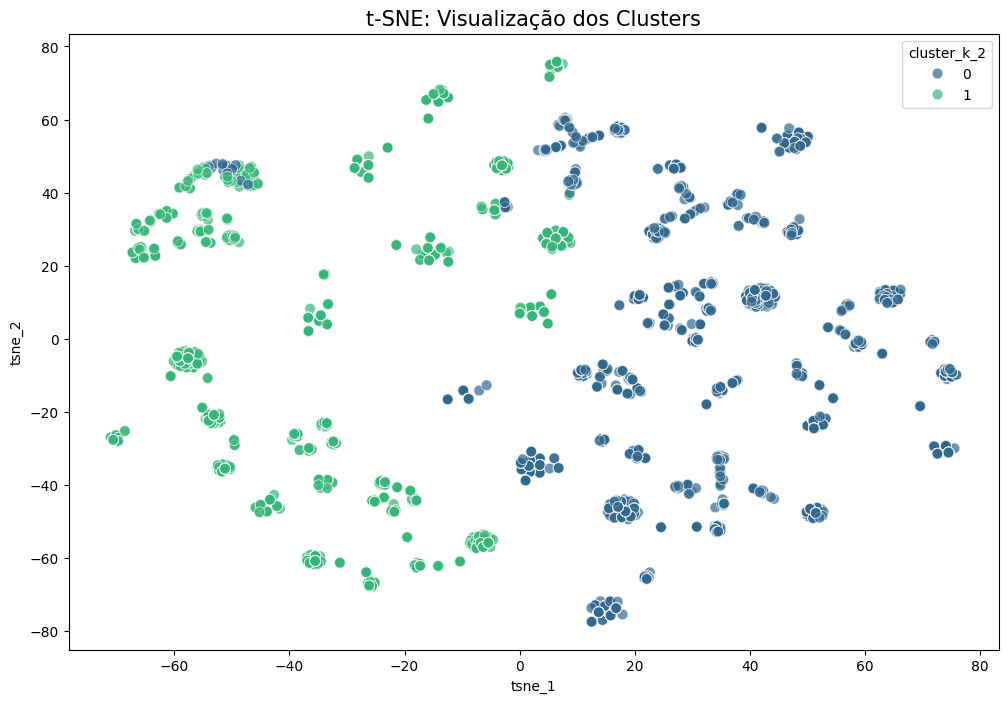

In [39]:
amostra_indices = df_sample.sample(n=5000, random_state=42).index

X_tsne_input = df_scaled_menor.loc[amostra_indices]

tsne = TSNE(n_components=2, perplexity=40, random_state=42, n_jobs=-1)
X_tsne_coords = tsne.fit_transform(X_tsne_input)

df_plot = df_sample.loc[amostra_indices].copy()
df_plot['tsne_1'] = X_tsne_coords[:, 0]
df_plot['tsne_2'] = X_tsne_coords[:, 1]

plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='tsne_1', 
    y='tsne_2', 
    hue='cluster_k_2', 
    data=df_plot,
    palette='viridis',
    alpha=0.7,
    s=60
)

plt.title('t-SNE: Visualização dos Clusters', fontsize=15)
plt.show()

In [40]:
s_score_k_2 = silhouette_score(df_scaled_menor, df_sample['cluster_k_2'])
db_score_k_2 = davies_bouldin_score(df_scaled_menor, df_sample['cluster_k_2'])
ch_score_k_2 = calinski_harabasz_score(df_scaled_menor, df_sample['cluster_k_2'])

print(f"Silhouette Score: {s_score_k_2:.4f} (Alvo: > 0.25)")
print(f"Davies-Bouldin Index: {db_score_k_2:.4f} (Quanto menor, melhor)")
print(f"Calinski-Harabasz Index: {ch_score_k_2:.4f} (Quanto maior, melhor)")

Silhouette Score: 0.1782 (Alvo: > 0.25)
Davies-Bouldin Index: 2.1051 (Quanto menor, melhor)
Calinski-Harabasz Index: 3760.4470 (Quanto maior, melhor)


#### Para k = 5

In [ ]:
kmeans_k_2 = KMeans(n_clusters=5, init="k-means++", random_state=42)
df_sample["cluster_k_5"] = kmeans_k_2.fit_predict(df_scaled_menor)
df_sample.groupby("cluster_k_5").mean(numeric_only=True)

,mortos,feridos,capital,dia,dia_util,rodovia_federal,cluster_k_2
cluster_k_5,,,,,,,
0,0.000177,1.343495,0.151188,0.662531,0.718540,0.998050,0.000000
1,0.000000,1.493472,0.037826,0.628264,0.668203,0.999040,0.691244
2,0.000000,1.445747,0.071181,0.575738,0.694661,0.999566,0.305339
3,1.191384,0.872175,0.049435,0.473164,0.642655,1.000000,0.911723
4,0.000000,0.000000,0.083813,0.526871,0.628919,0.987204,1.000000


A distibuição foi parcialmente proporcional, sendo o grupo 3 representante do caso mais raro

In [42]:
df_sample['cluster_k_5'].value_counts()

cluster_k_5
0    5642
1    5208
2    4608
4    3126
3    1416
Name: count, dtype: int64

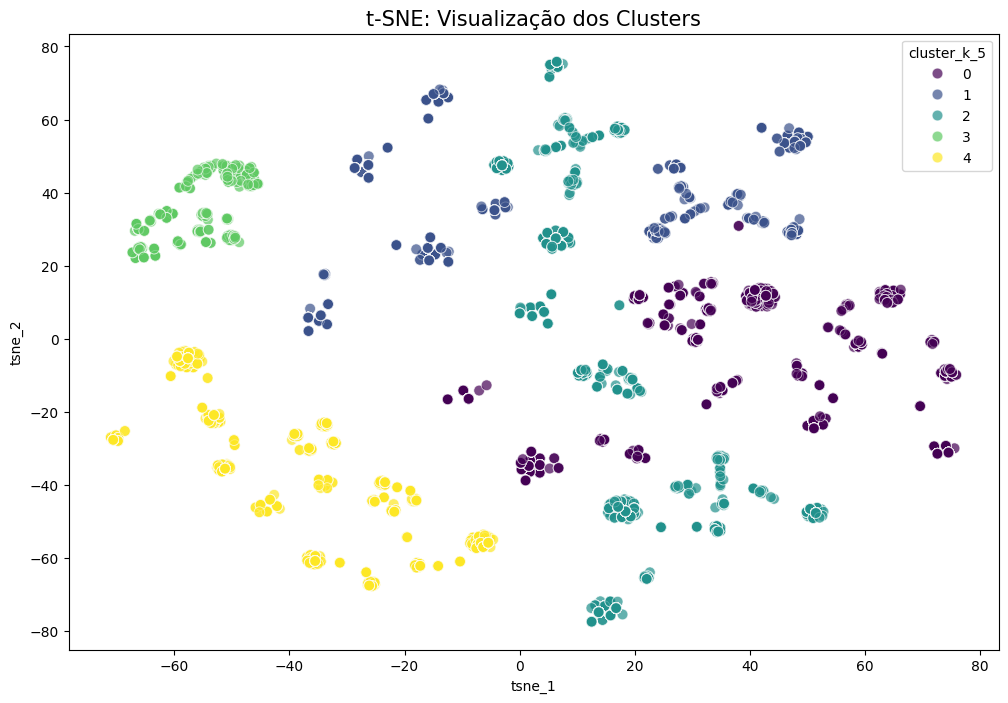

In [43]:
amostra_indices = df_sample.sample(n=5000, random_state=42).index

X_tsne_input = df_scaled_menor.loc[amostra_indices]

tsne = TSNE(n_components=2, perplexity=40, random_state=42, n_jobs=-1)
X_tsne_coords = tsne.fit_transform(X_tsne_input)

df_plot = df_sample.loc[amostra_indices].copy()
df_plot['tsne_1'] = X_tsne_coords[:, 0]
df_plot['tsne_2'] = X_tsne_coords[:, 1]

plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='tsne_1', 
    y='tsne_2', 
    hue='cluster_k_5', 
    data=df_plot,
    palette='viridis',
    alpha=0.7,
    s=60
)

plt.title('t-SNE: Visualização dos Clusters', fontsize=15)
plt.show()

In [44]:
s_score_k_5 = silhouette_score(df_scaled_menor, df_sample['cluster_k_5'])
db_score_k_5 = davies_bouldin_score(df_scaled_menor, df_sample['cluster_k_5'])
ch_score_k_5 = calinski_harabasz_score(df_scaled_menor, df_sample['cluster_k_5'])

print(f"Silhouette Score: {s_score_k_5:.4f} (Alvo: > 0.25)")
print(f"Davies-Bouldin Index: {db_score_k_5:.4f} (Quanto menor, melhor)")
print(f"Calinski-Harabasz Index: {ch_score_k_5:.4f} (Quanto maior, melhor)")

Silhouette Score: 0.2943 (Alvo: > 0.25)
Davies-Bouldin Index: 1.2617 (Quanto menor, melhor)
Calinski-Harabasz Index: 6816.4559 (Quanto maior, melhor)


#### Para k = 8

In [45]:
kmeans_k_2 = KMeans(n_clusters=8, init="k-means++", random_state=42)
df_sample["cluster_k_8"] = kmeans_k_2.fit_predict(df_scaled_menor)
df_sample.groupby("cluster_k_8").mean(numeric_only=True)

,mortos,feridos,capital,dia,dia_util,rodovia_federal,cluster_k_2,cluster_k_5
cluster_k_8,,,,,,,,
0,0.009990,3.109895,0.105614,0.809705,0.642721,0.998573,0.000000,0.790676
1,0.000000,1.246258,0.066634,0.000000,0.626268,0.999034,0.625785,0.844520
2,0.000000,1.274979,0.050378,0.540302,0.706549,0.999580,0.590680,2.000000
3,1.191565,0.728377,0.049321,0.470336,0.645461,1.000000,0.922802,3.000000
4,0.000000,1.217995,0.115488,0.000000,0.666965,0.998209,0.000000,0.673232
5,0.000000,1.000000,0.143474,1.000000,0.752697,0.998652,0.000000,0.490291
6,0.000000,0.000000,0.083813,0.526871,0.628919,0.987204,1.000000,4.000000
7,0.000000,1.226326,0.036602,1.000000,0.715245,0.998993,0.773674,1.000000


Também foi observada uma boa distribuição das instâncias entre os clusters

In [46]:
df_sample['cluster_k_8'].value_counts()

cluster_k_8
5    3708
6    3126
7    2978
2    2382
4    2234
0    2102
1    2071
3    1399
Name: count, dtype: int64

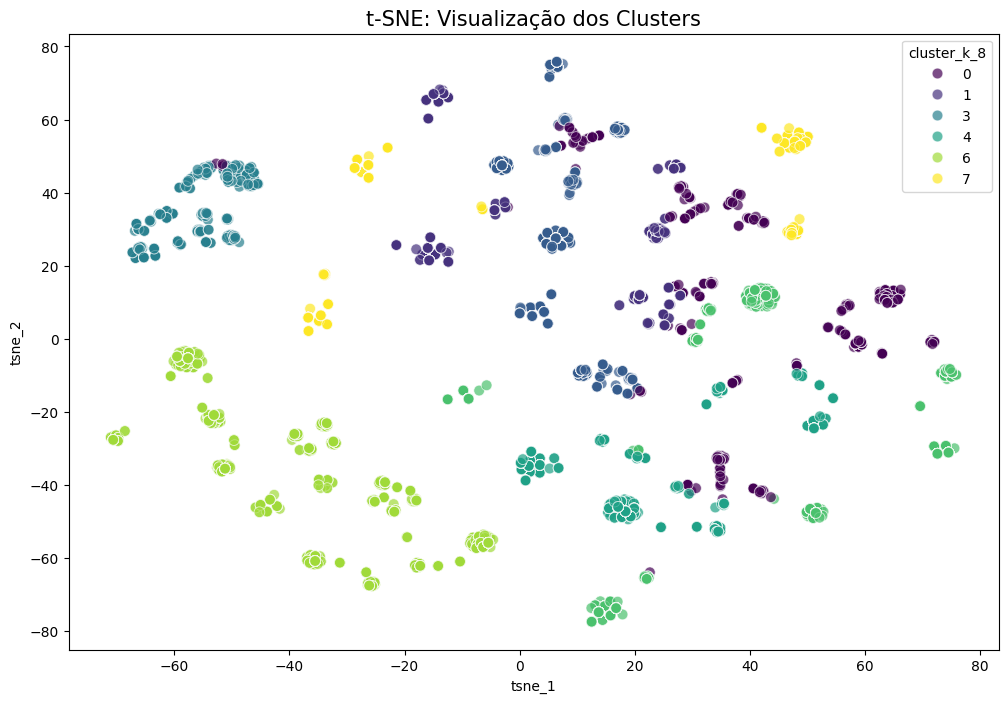

In [47]:
amostra_indices = df_sample.sample(n=5000, random_state=42).index

X_tsne_input = df_scaled_menor.loc[amostra_indices]

tsne = TSNE(n_components=2, perplexity=40, random_state=42, n_jobs=-1)
X_tsne_coords = tsne.fit_transform(X_tsne_input)

df_plot = df_sample.loc[amostra_indices].copy()
df_plot['tsne_1'] = X_tsne_coords[:, 0]
df_plot['tsne_2'] = X_tsne_coords[:, 1]

plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='tsne_1', 
    y='tsne_2', 
    hue='cluster_k_8', 
    data=df_plot,
    palette='viridis',
    alpha=0.7,
    s=60
)

plt.title('t-SNE: Visualização dos Clusters', fontsize=15)
plt.show()

In [48]:
s_score_k_8 = silhouette_score(df_scaled_menor, df_sample['cluster_k_8'])
db_score_k_8 = davies_bouldin_score(df_scaled_menor, df_sample['cluster_k_8'])
ch_score_k_8 = calinski_harabasz_score(df_scaled_menor, df_sample['cluster_k_8'])

print(f"Silhouette Score: {s_score_k_8:.4f} (Alvo: > 0.25)")
print(f"Davies-Bouldin Index: {db_score_k_8:.4f} (Quanto menor, melhor)")
print(f"Calinski-Harabasz Index: {ch_score_k_8:.4f} (Quanto maior, melhor)")

Silhouette Score: 0.2811 (Alvo: > 0.25)
Davies-Bouldin Index: 1.3595 (Quanto menor, melhor)
Calinski-Harabasz Index: 4958.1953 (Quanto maior, melhor)


### Interpretação

A comparação de desempenho entre todos os K testados indica que a divisão em 5 clusters foi a mais bem sucedida. <br>
* A métrica de Silhouette indica maior coesão interna entre instâncias de mesmo cluster, e melhor separação entre os demais. <br>
* Ao mesmo tempo, o Dives-Bouldin index apresentou a menor taxa nessa experimentação, indicando menor similaridade média entre os clusters. <br>
* E por fim, o index de Calinki Harabasz apresentou o maior número, indicando melhor dispersão entre clusters <br>

Apesar disso, a taxa de silhouette próxima a 0.29 ainda indica uma estrutura de clusterização não muito bem definida. Um possível indicador de dificuldade em definir padrões para acidentes de trânsito

In [54]:
df_scaled_menor['cluster_k_5'] = df_sample['cluster_k_5']

C:\Users\Hanny\AppData\Local\Temp\ipykernel_7296\227349341.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_scaled_menor['cluster_k_5'] = df_sample['cluster_k_5']


In [56]:
df_sample.groupby("cluster_k_5")[[c for c in df_sample.columns if c in ['mortos', 'feridos']]].mean()

,mortos,feridos
cluster_k_5,,
0,0.000177,1.343495
1,0.000000,1.493472
2,0.000000,1.445747
3,1.191384,0.872175
4,0.000000,0.000000


In [59]:
df_scaled_menor.groupby("cluster_k_5").mean()

,capital,dia,dia_util,tipo_pista_Dupla,tipo_pista_Múltipla,tipo_pista_Simples,meteorologia_Adversa,meteorologia_Desconhecido,meteorologia_Normal,mortos_log,feridos_log
cluster_k_5,,,,,,,,,,,
0,0.151188,0.662531,0.718540,0.810174,0.189826,0.000000,0.000000,0.012052,0.987948,-0.266145,0.334974
1,0.037826,0.628264,0.668203,0.000000,0.000192,0.999808,0.000000,0.019393,0.980607,-0.266755,0.441195
2,0.071181,0.575738,0.694661,0.438368,0.108507,0.453125,0.997613,0.002387,0.000000,-0.266755,0.401097
3,0.049435,0.473164,0.642655,0.274718,0.061441,0.663842,0.264831,0.016949,0.718220,3.498536,-0.727869
4,0.083813,0.526871,0.628919,0.442418,0.083813,0.473768,0.303263,0.014395,0.682342,-0.266755,-1.601172


In [57]:
df_sample["cluster_k_5"].value_counts()

cluster_k_5
0    5642
1    5208
2    4608
4    3126
3    1416
Name: count, dtype: int64

#### Descrição dos clusters 

cluster 0:

- mais representativa de capitais
- maior ocorrencia de dias úteis
- maior ocorrencia de pista dupla
- meteorologia normal
- poucos feridos e mortos
- maior grupo

cluster 1:

- menor ocorrência em capitais
- maioria em pista simples
- meteorologia normal
- poucos feridos e zero mortos
- segundo maior grupo

cluster 2:

- pouca ocorrência em capitais
- dia/noite equilibrados
- representação de pistas simples/duplas equilibrados
- meteorologia adversa (~99%)
- zero mortos e poucos feridos

cluster 3: 

- maior representativo noturno (~53%)
- dias úteis (~64%)
- maior ocorrência de simples (~66%)
- metereologia normal (~70%)
- cluster com maior número de mortos
- menor grupo

cluster 4:

- zero mortos e feridos 
- 2º menor grupo
- equilíbrio entre pistas duplas/simples
- meteorologia normal (~68%)


A partir desse comparativo, é possível a interpretação dos perfis:

###### Cluster 0 - Acidentes urbanos típicos
    Representam um alto volume, mas com baixa letalidade. 
    Envolvem as capitais, dias úteis e pistas duplas.

###### Cluster 1 - Rodovias simples em condições normais
    Quase totalmente representada por pistas simples, fora de capitais, com meteorologia normal. 
    Ferimentos leves, e zero mortos. Condições típicas.

###### Cluster 2 - Acidentes em condições adversas
    Maior representativa de meteorologia adversa, envolve alguns feridos, mas zero mortos.
    Possivelmente a baixa taxa de letalidade se dá às precauções assumidas pelos motoristas em condições climáticas adversas, como redução de velocidade e atenção redobrada.

###### Cluster 3 - Acidentes fatais 
    Grupo mais crítico e raro, concentra a maior taxa de letalidade. 
    Baixa representatividade em capitais, que podem indicar menor condição de segurança.

###### Cluster 4 - Acidentes sem vítimas
    Grupo mais saudável, sem mortos ou feridos. 
